# Embedding & Attention Weight Analysis

Split from the original combined "Attention Weights, Embeddings & Partial Charge Probe" notebook — this half covers embeddings and attention only. See `partial_charge_probe.ipynb` (moved alongside this notebook into `notebooks/`) for the partial charge probe.

Probes the internal representations of a trained model **without modifying any weights**, to understand how attention allocates information across atom types and residues, and whether the model's learned atom embeddings are chemically meaningful.

## Sections

- **1a** Atom-type embedding cosine similarity — do chemically similar elements cluster in embedding space?
- **1b** Per-element attention weights — does the AQ cross-attention differentiate by chemistry, or just by atom abundance?
- **1b-i** Per-residue attention — does amino-acid context modulate attention allocation beyond element identity?
- **1c** Cross-model embedding comparison — do AttentionESPN and DistanceESPN converge to similar atom representations despite different aggregation mechanisms?

## Key Findings (re-run 2026-09-21 against the slim-graph-retrained checkpoints, 848-protein test split)

- Per-element attention weights still differentiate meaningfully by chemistry, not just abundance: oxygen draws visibly higher and more variable attention than nitrogen in every head (Head 0: O 0.083±0.190 vs. N 0.011±0.030; Head 2: O 0.258±0.298 vs. N 0.013±0.079) despite nitrogen having comparable edge counts (8.7M vs. O's 9.4M) — consistent with electronegativity-driven, not purely geometric/abundance-driven, weighting. Same qualitative pattern as before retraining, numbers shifted but the O≫N gap, if anything, widened in Head 2.
- Per-residue attention (§1b-i) is **more specific than previously stated**: acidic residues (GLU 0.063±0.161 Head 0, ASP 0.074±0.178 Head 0) clearly stand out from hydrophobic ones (ALA 0.026, VAL 0.020, LEU 0.020, all Head 0) — but basic residues (ARG 0.022, LYS 0.021, Head 0) do **not** show the same elevation; they sit in the same range as the hydrophobics. The earlier framing ("charged/polar residues generally show higher-variance attention") over-generalized from acidic to charged-in-general — the effect is specifically acidic, not charge-sign-symmetric.
- See the cell outputs above for the full per-element/per-residue tables and the §1c cross-model embedding similarity comparison.

> **Models:** `EMBED_MODEL`/`COMPARE_MODEL` point at the two full-dataset champions, migrated 2026-09-18 to the slim graph format — `checkpoints/full_dataset_slim/attention_aa4_aq2_qq16` and `checkpoints/full_dataset_slim/distance_aa8_aq2_qq24` (previously `checkpoints/full_dataset/...`, the legacy-graph versions; see THESISPROCESSES.md "Graph Storage — Slim Edge Attributes").

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(Path("../..").resolve()))

from src.analysis.embedding_analysis import (
    ELEMENT_NAMES,
    RESIDUE_NAMES,
    collect_attention_stats,
    collect_attention_stats_residue,
    compare_embedding_tables,
    embedding_cosine_sim,
    load_model_frozen,
    _load_graph,
)
from src.analysis.charge_probe import (
    ChargeProbe,
    evaluate_probe,
    extract_atom_embeddings,
    read_pqr_charges,
    read_pqr_atoms,
    train_probe,
)
from src.data.dataset import load_split_manifest
from src.models.attention_espn import AttentionESPN
from src.utils.config import get_data_root
from src.utils.paths import ProteinPaths

/home/student/miniconda3/envs/pyg_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

`EMBED_MODEL` is the checkpoint used for embedding and attention analysis. `COMPARE_MODEL` is a second checkpoint for cross-model embedding comparison (set to `None` to skip §1c).

In [2]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = THESIS_ROOT / "full_protein_dataset_slim"  # explicit -- matches what these checkpoints were retrained on

EMBED_MODEL   = CKPT_ROOT / "full_dataset_slim" / "attention_aa4_aq2_qq16"
# Second model for cross-model comparison (can be None to skip 1c)
COMPARE_MODEL = CKPT_ROOT / "full_dataset_slim" / "distance_aa8_aq2_qq24"

print(f"EMBED_MODEL:   {EMBED_MODEL}  (exists: {EMBED_MODEL.exists()})")
print(f"COMPARE_MODEL: {COMPARE_MODEL}  (exists: {COMPARE_MODEL.exists()})")

EMBED_MODEL:   /home/student/thesis/checkpoints/full_dataset_slim/attention_aa4_aq2_qq16  (exists: True)
COMPARE_MODEL: /home/student/thesis/checkpoints/full_dataset_slim/distance_aa8_aq2_qq24  (exists: True)


---
## 1. Embeddings & Attention Weights

### 1a. Atom-type embedding cosine similarity

Pairwise cosine similarity between the rows of the `AtomEncoder`'s element embedding table. If the model has learned chemically meaningful representations, electronegative elements (O, N) should cluster together and away from carbon; hydrogen should occupy its own region. A near-uniform matrix indicates the embeddings are not well-differentiated by element.

Loaded attention from attention_aa4_aq2_qq16
  hidden_dim=256  feature_spec={'query_curvature': False, 'query_normal': False}


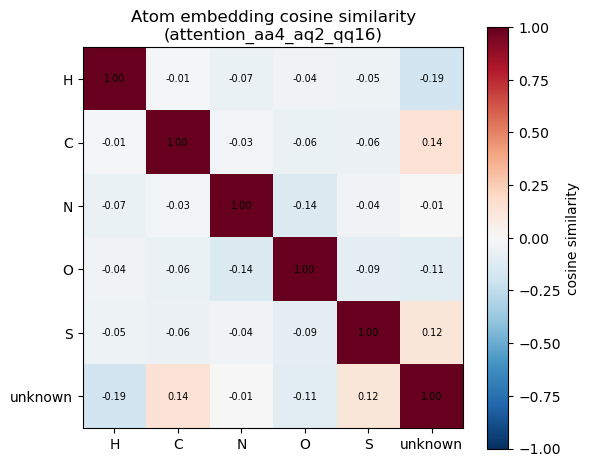

In [3]:
if not EMBED_MODEL.exists():
    print(f"Checkpoint not found: {EMBED_MODEL} — run the sweep first.")
else:
    model_a, ckpt_a = load_model_frozen(EMBED_MODEL, DEVICE)
    print(f"Loaded {ckpt_a['model_name']} from {EMBED_MODEL.name}")
    print(f"  hidden_dim={ckpt_a['model_config']['hidden_dim']}  "
          f"feature_spec={ckpt_a.get('feature_spec', {})}")

    sim, labels = embedding_cosine_sim(model_a)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(sim, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, label="cosine similarity")
    ax.set_title(f"Atom embedding cosine similarity\n({EMBED_MODEL.name})")
    plt.tight_layout()
    plt.show()

### 1b. Per-element attention weights

Mean attention weight α per element per head, collected over all AQ edges in the test split. A flat distribution across elements would indicate the model attends purely by geometric proximity (abundance); systematic differentiation by element indicates the model uses atom chemistry to modulate how much information each atom type contributes to a query node's representation.

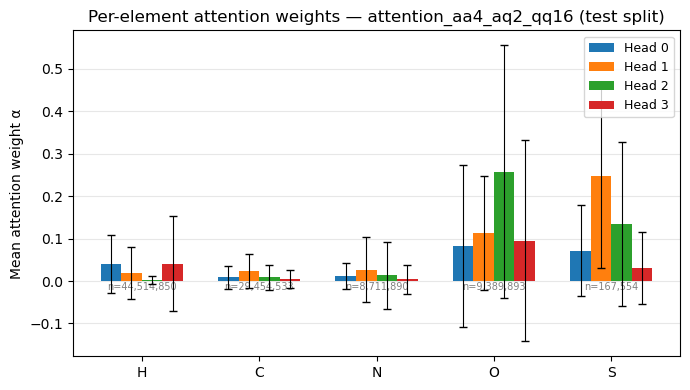


Mean α ± std per element per head  (model=attention_aa4_aq2_qq16)


,Element,N edges,Head 0,Head 1,Head 2,Head 3
0,H,44514850,0.0393 ± 0.0680,0.0189 ± 0.0603,0.0016 ± 0.0093,0.0407 ± 0.1115
1,C,29454533,0.0084 ± 0.0263,0.0237 ± 0.0404,0.0086 ± 0.0302,0.0049 ± 0.0216
2,O,9389893,0.0829 ± 0.1902,0.1134 ± 0.1350,0.2576 ± 0.2979,0.0945 ± 0.2368
3,N,8711890,0.0110 ± 0.0304,0.0269 ± 0.0772,0.0131 ± 0.0787,0.0042 ± 0.0345
4,S,167554,0.0715 ± 0.1067,0.2463 ± 0.2158,0.1344 ± 0.1940,0.0305 ± 0.0852


In [4]:
if not EMBED_MODEL.exists():
    print(f"Checkpoint not found: {EMBED_MODEL}")
elif not isinstance(model_a, AttentionESPN):
    print(f"{EMBED_MODEL.name} is a distance model — no cross-attention to inspect.")
else:
    _, _, test_ids = load_split_manifest(DATA_ROOT)
    print(f"Collecting attention stats over {len(test_ids)} test proteins...")
    attn_stats = collect_attention_stats(model_a, test_ids, DATA_ROOT, DEVICE)

    present   = [(name, attn_stats[name]) for name in ELEMENT_NAMES if attn_stats[name]["count"] > 0]
    names     = [p[0] for p in present]
    means_arr = np.array([p[1]["mean"] for p in present])
    stds_arr  = np.array([p[1]["std"]  for p in present])
    counts    = [p[1]["count"] for p in present]
    n_heads   = means_arr.shape[1]

    fig, ax = plt.subplots(figsize=(max(7, len(names)), 4))
    total_width = 0.7
    bar_w = total_width / n_heads
    x = np.arange(len(names))
    for h in range(n_heads):
        offsets = x + h * bar_w - total_width / 2 + bar_w / 2
        ax.bar(offsets, means_arr[:, h], width=bar_w, label=f"Head {h}", zorder=3)
        ax.errorbar(offsets, means_arr[:, h], yerr=stds_arr[:, h],
                    fmt="none", color="black", capsize=3, linewidth=0.8, zorder=4)
    for i, (xi, cnt) in enumerate(zip(x, counts)):
        ax.text(xi, -0.003, f"n={cnt:,}", ha="center", va="top", fontsize=7, color="gray")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylabel("Mean attention weight α")
    ax.set_title(f"Per-element attention weights — {EMBED_MODEL.name} (test split)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

    rows_el = []
    for name, s in present:
        row = {"Element": name, "N edges": s["count"]}
        for h, (m, sd) in enumerate(zip(s["mean"], s["std"])):
            row[f"Head {h}"] = f"{m:.4f} ± {sd:.4f}"
        rows_el.append(row)
    df_el = pd.DataFrame(rows_el).sort_values("N edges", ascending=False)
    print(f"\nMean α ± std per element per head  (model={EMBED_MODEL.name})")
    display(df_el.reset_index(drop=True))

#### 1b-i. Attention weights — residue × head heatmap

Does the model attend differently to atoms depending on which amino acid they belong to?
A uniform heatmap suggests element identity matters more than residue context.

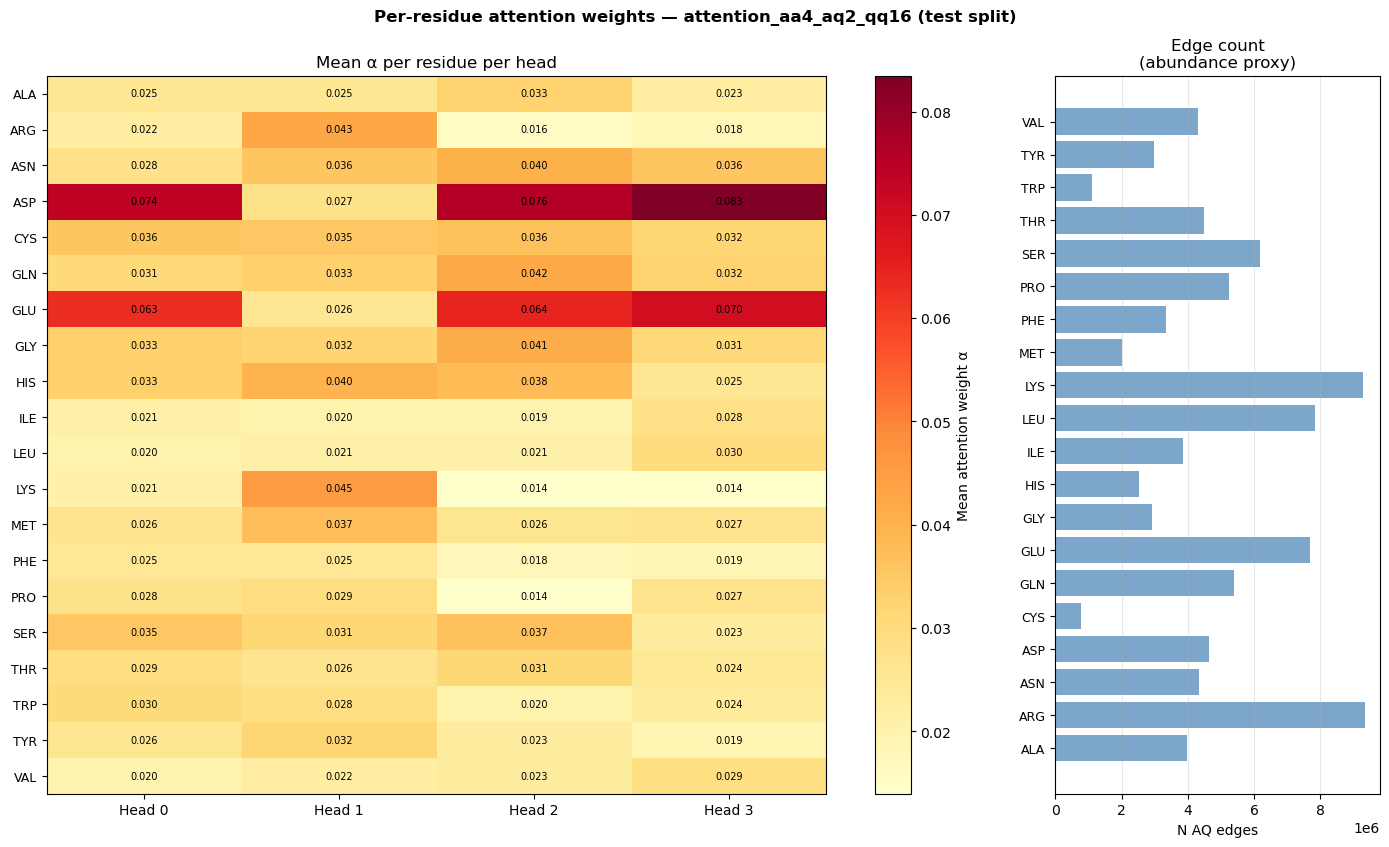


Mean α ± std per residue per head  (model=attention_aa4_aq2_qq16)


,Residue,N edges,Head 0,Head 1,Head 2,Head 3
0,ARG,9331192,0.0222 ± 0.0559,0.0426 ± 0.0872,0.0156 ± 0.0755,0.0179 ± 0.0718
1,LYS,9289435,0.0206 ± 0.0479,0.0451 ± 0.1037,0.0140 ± 0.0783,0.0140 ± 0.0669
2,LEU,7835140,0.0201 ± 0.0436,0.0208 ± 0.0559,0.0212 ± 0.0960,0.0300 ± 0.0988
3,GLU,7697272,0.0626 ± 0.1614,0.0255 ± 0.0612,0.0644 ± 0.1947,0.0701 ± 0.2030
4,SER,6184939,0.0352 ± 0.0709,0.0314 ± 0.0756,0.0367 ± 0.1325,0.0229 ± 0.0666
5,GLN,5391378,0.0308 ± 0.0623,0.0332 ± 0.0749,0.0420 ± 0.1535,0.0324 ± 0.1124
6,PRO,5246862,0.0275 ± 0.0557,0.0289 ± 0.0606,0.0141 ± 0.0665,0.0270 ± 0.0923
7,ASP,4643792,0.0740 ± 0.1776,0.0273 ± 0.0587,0.0759 ± 0.2062,0.0835 ± 0.2223
8,THR,4501445,0.0289 ± 0.0617,0.0263 ± 0.0669,0.0315 ± 0.1238,0.0244 ± 0.0764
9,ASN,4350133,0.0276 ± 0.0589,0.0359 ± 0.0815,0.0403 ± 0.1412,0.0358 ± 0.1166


In [5]:
if not EMBED_MODEL.exists():
    print(f"Checkpoint not found: {EMBED_MODEL}")
elif not isinstance(model_a, AttentionESPN):
    print(f"{EMBED_MODEL.name} is a distance model — no cross-attention.")
else:
    _, _, test_ids = load_split_manifest(DATA_ROOT)
    print(f"Collecting residue-level attention stats over {len(test_ids)} test proteins...")
    res_stats = collect_attention_stats_residue(model_a, test_ids, DATA_ROOT, DEVICE)

    present_res = [(name, res_stats[name]) for name in RESIDUE_NAMES if res_stats[name]["count"] > 0]
    res_names_p = [p[0] for p in present_res]
    res_means   = np.array([p[1]["mean"] for p in present_res])
    res_counts  = [p[1]["count"] for p in present_res]
    n_heads_r   = res_means.shape[1]

    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(res_names_p) * 0.38 + 1)),
                             gridspec_kw={"width_ratios": [3, 1]})
    fig.suptitle(f"Per-residue attention weights — {EMBED_MODEL.name} (test split)",
                 fontsize=12, fontweight="bold")

    ax = axes[0]
    im = ax.imshow(res_means, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(n_heads_r))
    ax.set_xticklabels([f"Head {h}" for h in range(n_heads_r)], fontsize=10)
    ax.set_yticks(range(len(res_names_p)))
    ax.set_yticklabels(res_names_p, fontsize=9)
    for i in range(len(res_names_p)):
        for j in range(n_heads_r):
            ax.text(j, i, f"{res_means[i, j]:.3f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, label="Mean attention weight α")
    ax.set_title("Mean α per residue per head")

    ax = axes[1]
    y = np.arange(len(res_names_p))
    ax.barh(y, res_counts, color="steelblue", alpha=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(res_names_p, fontsize=9)
    ax.set_xlabel("N AQ edges")
    ax.set_title("Edge count\n(abundance proxy)")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    rows_res = []
    for name, s in present_res:
        row = {"Residue": name, "N edges": s["count"]}
        for h, (m, sd) in enumerate(zip(s["mean"], s["std"])):
            row[f"Head {h}"] = f"{m:.4f} ± {sd:.4f}"
        rows_res.append(row)
    df_res = pd.DataFrame(rows_res).sort_values("N edges", ascending=False)
    print(f"\nMean α ± std per residue per head  (model={EMBED_MODEL.name})")
    display(df_res.reset_index(drop=True))

### 1c. Cross-model embedding comparison

Per-element cosine similarity between the `AtomEncoder` embedding tables of the attention and distance models. High similarity across elements indicates both models converged to similar atom representations despite different Stage 2 aggregation mechanisms — suggesting the encoder and Stage 1 rounds are the primary drivers of atom representation quality, not the AQ aggregation style.

Loaded distance from distance_aa8_aq2_qq24


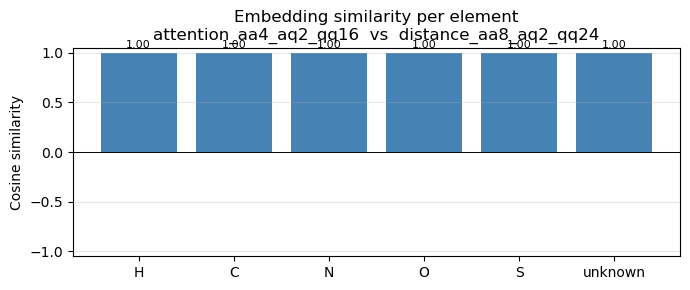

In [6]:
if not EMBED_MODEL.exists() or not COMPARE_MODEL.exists():
    missing = [p for p in [EMBED_MODEL, COMPARE_MODEL] if not p.exists()]
    print(f"Skipping — checkpoint(s) not found: {[p.name for p in missing]}")
else:
    model_b, ckpt_b = load_model_frozen(COMPARE_MODEL, DEVICE)
    print(f"Loaded {ckpt_b['model_name']} from {COMPARE_MODEL.name}")

    sims = compare_embedding_tables(model_a, model_b)

    fig, ax = plt.subplots(figsize=(7, 3))
    x    = np.arange(len(ELEMENT_NAMES))
    bars = ax.bar(x, sims, color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(ELEMENT_NAMES)
    ax.set_ylim(-1.05, 1.05)
    ax.axhline(0, color="k", linewidth=0.7)
    ax.set_ylabel("Cosine similarity")
    ax.set_title(f"Embedding similarity per element\n{EMBED_MODEL.name}  vs  {COMPARE_MODEL.name}")
    for bar, val in zip(bars, sims):
        offset = 0.03 if val >= 0 else -0.07
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()